# AI/ML Bootcamp Lecture 3 - Part 2

## MNIST Handwritten digit classifier
For this in-class exercise we will look at the MNIST handwritten digit dataset and classify them using different types of neural networks using keras and tensorflow.

### Homework
- Choose at least two datasets to train a new NN Classifier on
- Describe why you chose your model
- Describe any difficulties you had in training your neural network

### Requirements:
- You should show the accuracy of your model
- You should use markdown appropriately for annotating your code and answering the questions above
- Your jupyter notebook should be committed to gitlab after you go to kernel and "Restart kernel and run all"

### Imports and style

In [ ]:
from tensorflow.keras.datasets import mnist
from tensorflow import keras
from tensorflow.keras import layers
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import pandas as pd
import matplotlib.pyplot as plt
height = 5
plt.rcParams["figure.figsize"] = [1.618*height, height]

### Load the MNIST data into a NumPy arrays

In [ ]:
from tensorflow.keras.datasets import mnist
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

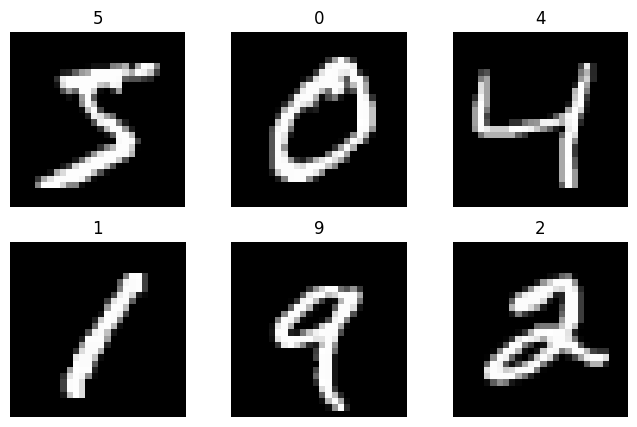

In [ ]:
# Plot 6 images from the training set
plt.figure()
for i in range(6):
    plt.subplot(2, 3, i+1)
    plt.imshow(train_images[i], cmap='gray')
    plt.title(train_labels[i])
    plt.axis('off')
plt.show();

In [ ]:
# Build a MLP
model = keras.Sequential()
model.add(layers.Flatten(input_shape=(28, 28)))
model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))
model.summary();

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 932,362 (3.56 MB)

 Trainable params: 932,362 (3.56 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
# Train the model
history = model.fit(train_images,
                    train_labels,
                    epochs=150,
                    batch_size=128,
                    validation_split=0.2)

Epoch 1/150
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8930 - loss: 1.7388 - val_accuracy: 0.9338 - val_loss: 0.3165
Epoch 2/150
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9563 - loss: 0.1808 - val_accuracy: 0.9492 - val_loss: 0.2401
Epoch 3/150
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9684 - loss: 0.1228 - val_accuracy: 0.9566 - val_loss: 0.2043
Epoch 4/150
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9729 - loss: 0.1018 - val_accuracy: 0.9573 - val_loss: 0.2015
Epoch 5/150
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9773 - loss: 0.0874 - val_accuracy: 0.9584 - val_loss: 0.2217
Epoch 6/150
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9754 - loss: 0.0929 - val_accuracy: 0.9634 - val_loss: 0.2013
Epoch 7/150
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9781 - loss: 0.0833 - val_accuracy: 0.9570 - val_loss: 0.2024
Epoch 8/150
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9781 - loss: 0.0794 - val_accu

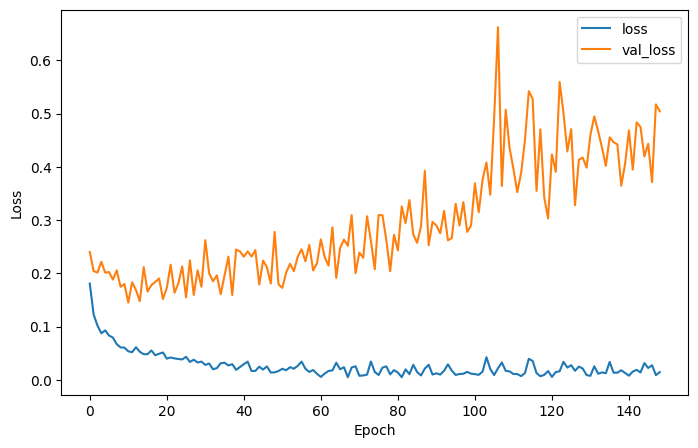

In [ ]:
# Plot loss and val loss
plt.plot(history.history['loss'][1:], label='loss')
plt.plot(history.history['val_loss'][1:], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend();